In [17]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Initialize the input vector and output vector for XOR

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

Y = np.array([
    [0],
    [1],
    [1],
    [0]
])

print("Input:\n", X)
print("\nOutput:\n", Y)

Input:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]

Output:
 [[0]
 [1]
 [1]
 [0]]


In [19]:
#Initialize the structure of  MLP with input ,hidden  and output layer

input_neurons = 2
hidden_neurons = 2
output_neurons = 1

learning_rate = 0.1
epochs = 10000

print("Input Neurons :", input_neurons)
print("Hidden Neurons:", hidden_neurons)
print("Output Neurons:", output_neurons)


Input Neurons : 2
Hidden Neurons: 2
Output Neurons: 1


In [20]:
# Weight matrix for hidden layer randomly

np.random.seed(42)

W1 = np.random.randn(input_neurons, hidden_neurons)
B1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons)
B2 = np.zeros((1, output_neurons))

print("W1:\n", W1)
print("\nW2:\n", W2)


W1:
 [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]]

W2:
 [[-0.23415337]
 [-0.23413696]]


In [21]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Sigmoid Derivative
def sigmoid_derivative(x):
    return x * (1 - x)


In [22]:
def forward_propagation(X, W1, B1, W2, B2):

    hidden_input = np.dot(X, W1) + B1

    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + B2

    predicted_output = sigmoid(final_input)

    return hidden_output, predicted_output

In [23]:
def backward_propagation(
        X,
        Y,
        hidden_output,
        predicted_output,
        W2):

    d_output = (
        Y - predicted_output
    ) * sigmoid_derivative(predicted_output)

    hidden_error = np.dot(
        d_output,
        W2.T
    )

    d_hidden = (
        hidden_error
    ) * sigmoid_derivative(hidden_output)

    return d_output, d_hidden

def update_weights(
        X,
        hidden_output,
        d_output,
        d_hidden,
        W1,
        B1,
        W2,
        B2,
        learning_rate):

    W2 += np.dot( hidden_output.T, d_output ) * learning_rate

    B2 += np.sum( d_output, axis=0, keepdims=True ) * learning_rate

    W1 += np.dot( X.T, d_hidden ) * learning_rate

    B1 += np.sum( d_hidden, axis=0, keepdims=True ) * learning_rate

    return W1, B1, W2, B2

In [24]:
#Train the MLP

def train_network():

    global W1, B1, W2, B2

    losses = []

    for epoch in range(epochs):

        hidden_output, predicted_output = forward_propagation(
            X,
            W1,
            B1,
            W2,
            B2
        )

        error = Y - predicted_output

        loss = np.mean(error ** 2)

        losses.append(loss)

        d_output, d_hidden = backward_propagation(
            X,
            Y,
            hidden_output,
            predicted_output,
            W2
        )

        W1, B1, W2, B2 = update_weights(
            X,
            hidden_output,
            d_output,
            d_hidden,
            W1,
            B1,
            W2,
            B2,
            learning_rate
        )

    return losses, predicted_output

losses, predicted_output = train_network()

print("Training Completed")



Training Completed


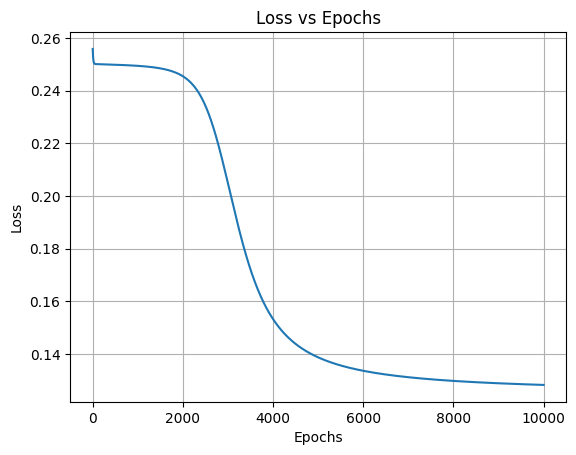

In [25]:
# plot losses to see how our network is doing

plt.plot(losses)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.grid(True)

In [28]:
#Test the XOR classification

print("Predicted Output")

print(predicted_output)

binary_output = (predicted_output > 0.5).astype(int)
print("\nBinary Output")
print(binary_output)

Predicted Output
[[0.05300868]
 [0.49554213]
 [0.95091319]
 [0.50319888]]

Binary Output
[[0]
 [0]
 [1]
 [1]]
